# Overall Flow
## Risk measurement

Risk is mainly measured by:

- Interest Coverage Ratio(ICR) = EBIT / Interest Expense

- The above factor will = 0 if the company is listed on the financial_violation list

- Market risk is measured through negative skewness


#### 3 dimensions of risk measurements:

| 风险类型 | 含义   |
|---------|--------|
| FV      | 财务崩溃 |
| Crash   | 市场崩溃 |
| ICR     | 融资压力 |



# Code

## Dataset

In [51]:
import pandas as pd

# Dataset copyright: Shenzhen CSMAR Data Technology Co., Ltd.
NQPF_score = pd.read_csv('NQPF_EnNQPLevelSP.csv')
income_statement = pd.read_csv('FS_Comins.csv')
balance_sheet = pd.read_csv('FS_Combas.csv')
cash_flow = pd.read_csv('FS_Comscfi.csv')
financial_violation = pd.read_csv('AEC_FinViolation.csv')
stock_price = pd.read_csv("TRDNEW_Mnth.csv")
NQPF_2_SP = pd.read_csv("NQPF_EnNQPScndLevelIndSP.csv")
NQPF_3_SP = pd.read_csv("NQPF_EnNQPThreeLevelIndSP.csv")
NQPF_LT = pd.read_csv("NQPF_EnNQPLevelLT.csv")
NQPF_2_LT = pd.read_csv("NQPF_EnNQPScndLevelIndLT.csv")
NQPF_3_LT = pd.read_csv("NQPF_EnNQPThreeLevelIndLT.csv")


In [52]:
# create a new dataframe
NQPF_risk = NQPF_score.iloc[:,[0,1,2,12]].copy()

In [53]:
# data transformation for income statement + balance sheet
# Remove Typrep == 'B'(A = consolidated income statement;B = income statement for parent company)
income_statement = income_statement[income_statement['Typrep'] != 'B']
balance_sheet = balance_sheet[balance_sheet['Typrep'] != 'B']

# Keep only year-end dates (income statement data is reported every quarter, but we only want annual figure)
income_statement = income_statement[income_statement['Accper'].str.endswith('-12-31')]
balance_sheet = balance_sheet[balance_sheet['Accper'].str.endswith('-12-31')]

In [54]:
# Data type conversion for income statement and balance sheet
NQPF_risk['EndDate'] = pd.to_datetime(
    NQPF_risk['EndDate'].astype(str) + '-12-31'
)

income_statement['Accper'] = pd.to_datetime(income_statement['Accper'])

In [55]:
# Merge with income_statement, selecting needed columns
# select EBIT and interest expense from the Income Statement
NQPF_risk = NQPF_risk.merge(
    income_statement[['Stkcd', 'Accper', 'B001300000', 'B001211101','B001100000']],
    left_on=['Symbol', 'EndDate'],
    right_on=['Stkcd', 'Accper'],
    how='left'
)

# Drop redundant merge keys
NQPF_risk = NQPF_risk.drop(columns=['Stkcd', 'Accper'])

# Rename columns
NQPF_risk = NQPF_risk.rename(columns={
    'B001300000': 'EBIT',
    'B001211101': 'Interest_Expense',
    'B001100000': 'Operating Revenue'
})

In [56]:
# new column "Interest Coverage Ratio(ICR)" computed
NQPF_risk['Interest Coverage Ratio(ICR)'] = (
    NQPF_risk['EBIT'] / NQPF_risk['Interest_Expense']
)

In [57]:
# adding a new column to record whether the company is on the list of Financial Violation
# Convert DeclareDate to datetime (if not already)
financial_violation['DeclareDate'] = pd.to_datetime(financial_violation['DeclareDate'])

# Keep year and set month/day to 12-31
financial_violation['DeclareDate'] = financial_violation['DeclareDate'].dt.year.astype(str) + '-12-31'

# Convert back to datetime
financial_violation['DeclareDate'] = pd.to_datetime(financial_violation['DeclareDate'])

In [58]:
# Merge directly into NQPF_risk and create flag
NQPF_risk = NQPF_risk.merge(
    financial_violation[['Symbol', 'DeclareDate']],
    left_on=['Symbol', 'EndDate'],
    right_on=['Symbol', 'DeclareDate'],
    how='left',
    indicator=True  # creates _merge column
)

# Create flag: 0 if match found, 1 otherwise
NQPF_risk['Financial_Violation_Flag'] = NQPF_risk['_merge'].apply(lambda x: 1 if x == 'both' else 0)

# Drop helper column
NQPF_risk = NQPF_risk.drop(columns=['DeclareDate', '_merge'])

In [59]:
# Adding items from Balance Sheet

balance_sheet['Accper'] = pd.to_datetime(balance_sheet['Accper'])
balance_sheet

,Stkcd,ShortName_EN,Accper,Typrep,IfCorrect,DeclareDate,A001101000,A0d1101101,A0d1102000,A0d1102101,...,A003105000,A003106000,A003107000,A0F3108000,A0F3109000,A003111000,A003100000,A003200000,A003000000,A004000000
6,1,PAYH,2020-12-31,A,0,NaN,NaN,NaN,NaN,NaN,...,1.311860e+11,NaN,NaN,NaN,NaN,4.620000e+08,3.641310e+11,NaN,3.641310e+11,4.468514e+12
16,1,PAYH,2021-12-31,A,0,NaN,NaN,NaN,NaN,NaN,...,1.543770e+11,NaN,NaN,NaN,NaN,1.785000e+09,3.954480e+11,NaN,3.954480e+11,4.921380e+12
26,1,PAYH,2022-12-31,A,0,NaN,NaN,NaN,NaN,NaN,...,1.863050e+11,NaN,NaN,NaN,NaN,2.660000e+09,4.346800e+11,NaN,4.346800e+11,5.321514e+12
36,1,PAYH,2023-12-31,A,0,NaN,NaN,NaN,NaN,NaN,...,2.212550e+11,NaN,NaN,NaN,NaN,2.264000e+09,4.723280e+11,NaN,4.723280e+11,5.587116e+12
46,1,PAYH,2024-12-31,A,0,NaN,NaN,NaN,NaN,NaN,...,2.436050e+11,NaN,NaN,NaN,NaN,2.127000e+09,4.948420e+11,NaN,4.948420e+11,5.769270e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242250,920992,ZKML,2020-12-31,A,0,NaN,3.396683e+08,NaN,NaN,NaN,...,5.916053e+07,NaN,NaN,NaN,NaN,NaN,1.786214e+08,NaN,1.786214e+08,5.122577e+08
242258,920992,ZKML,2021-12-31,A,0,NaN,3.305894e+08,NaN,NaN,NaN,...,1.153655e+08,NaN,NaN,NaN,NaN,NaN,2.417620e+08,NaN,2.417620e+08,5.198337e+08
242268,920992,ZKML,2022-12-31,A,0,NaN,5.820909e+08,NaN,NaN,NaN,...,1.035778e+08,NaN,NaN,NaN,269572.20,NaN,6.011533e+08,NaN,6.011533e+08,8.071261e+08
242278,920992,ZKML,2023-12-31,A,0,NaN,5.572548e+08,NaN,NaN,NaN,...,1.005609e+08,NaN,NaN,NaN,1936769.22,NaN,6.015200e+08,NaN,6.015200e+08,7.328239e+08


In [60]:
NQPF_risk = NQPF_risk.merge(
    balance_sheet[['Stkcd', 'Accper', 'A001100000', 'A001000000','A002100000','A003103000','A002000000','A001218000']],
    left_on=['Symbol', 'EndDate'],
    right_on=['Stkcd', 'Accper'],
    how='left'
)

# Drop redundant merge keys
NQPF_risk = NQPF_risk.drop(columns=['Stkcd', 'Accper'])

# Rename columns
NQPF_risk = NQPF_risk.rename(columns={
    'A001100000': 'Total Current Assets',
    'A001000000': 'Total Assets',
    'A002100000': 'Total Current Liabilities',
    'A003103000': 'surplus reserve(retained earnings)',
    'A002000000': 'Total Liabilities',
    'A001218000': 'Net Intangible Assets'
    
})

In [61]:
# Compute negative skewness

import pandas as pd
import numpy as np
from scipy.stats import skew

# Make a copy
df = stock_price.copy()

# Split Trdmnt: "2024-01" → Year=2024, Month=01
df[['Year', 'Month']] = df['Trdmnt'].str.split('-', expand=True)
df['Year'] = df['Year'].astype(int)
df['Month'] = df['Month'].astype(int)

# Sort by stock, year, month
df = df.sort_values(['Stkcd', 'Year', 'Month'])

# Compute monthly log returns
df['return'] = df.groupby('Stkcd')['Mclsprc'].transform(
    lambda x: np.log(x / x.shift(1))
)

# Compute annual negative skewness for each stock (if >10 months of data)
skew_df = (
    df.groupby(['Stkcd', 'Year'])['return']
      .apply(lambda x: -skew(x.dropna(), bias=False) if len(x.dropna()) > 10 else np.nan)
      .reset_index(name='Negative Skewness')
)

# Get year-end market capitalization (last month of the year)
mktcap_df = (
    df.sort_values(['Stkcd', 'Year', 'Month'])
      .groupby(['Stkcd', 'Year'])
      .tail(1)[['Stkcd', 'Year', 'Msmvttl']]
      .rename(columns={'Msmvttl': 'Market Cap'})
)

In [62]:
# Add results to NQPF_risk

# Extract Year from EndDate (format: "YYYY-12-31")
NQPF_risk['Year'] = pd.to_datetime(NQPF_risk['EndDate']).dt.year

# Merge year-end market cap
NQPF_risk = NQPF_risk.merge(
    mktcap_df,
    how='left',
    left_on=['Symbol', 'Year'],
    right_on=['Stkcd', 'Year']
).drop(columns=['Stkcd'])  # drop duplicate Stkcd column

# Merge negative skewness
NQPF_risk = NQPF_risk.merge(
    skew_df,
    how='left',
    left_on=['Symbol', 'Year'],
    right_on=['Stkcd', 'Year']
).drop(columns=['Stkcd'])  # drop duplicate Stkcd column

NQPF_risk = NQPF_risk.drop(columns=['Year'])

# Result: df now has 'year_end_mktcap' and 'neg_skewness'

In [63]:
NQPF_risk

,EndDate,InstitutionID,Symbol,EntProductivityLevel,EBIT,Interest_Expense,Operating Revenue,Interest Coverage Ratio(ICR),Financial_Violation_Flag,Total Current Assets,Total Assets,Total Current Liabilities,surplus reserve(retained earnings),Total Liabilities,Net Intangible Assets,Market Cap,Negative Skewness
0,2023-12-31,101775,2,0.000142,2.925170e+10,5.737473e+09,4.657391e+11,5.098359,0,1.150260e+12,1.504850e+12,8.217853e+11,1.262275e+11,1.101917e+12,1.095648e+10,1.017151e+08,-0.375183
1,2024-12-31,101775,2,0.000104,-4.564380e+10,7.446693e+09,3.431764e+11,-6.129405,0,9.175121e+11,1.286260e+12,7.190618e+11,1.262275e+11,9.474052e+11,8.297477e+09,7.059767e+07,-1.589640
2,2020-12-31,102295,5,0.001200,-3.848256e+08,2.810670e+07,3.989211e+08,-13.691599,0,1.368568e+09,2.468377e+09,1.126604e+09,1.495191e+08,1.135674e+09,5.998147e+07,2.678098e+06,-0.063019
3,2022-12-31,102295,5,0.000677,-9.535157e+07,1.271664e+07,2.837437e+08,-7.498172,0,1.494236e+09,2.602190e+09,8.187260e+08,1.495191e+08,1.293702e+09,5.094700e+07,1.968879e+06,0.479642
4,2020-12-31,102296,6,0.000084,1.086544e+09,1.792112e+08,2.934733e+09,6.062923,0,1.176674e+10,1.543476e+10,4.154819e+09,1.901355e+09,7.596762e+09,NaN,7.573472e+06,-0.684046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16112,2024-12-31,10375955,920985,0.000220,2.073870e+08,3.694981e+07,3.717455e+09,5.612666,0,3.573324e+09,5.421616e+09,2.761721e+09,8.818483e+07,3.991311e+09,1.722120e+08,3.094762e+06,-1.823097
16113,2020-12-31,10368903,920992,0.000002,4.902661e+07,1.186478e+06,3.722132e+08,41.321137,0,3.838398e+08,5.122577e+08,3.211237e+08,9.496524e+06,3.336364e+08,1.148939e+07,NaN,NaN
16114,2022-12-31,10368903,920992,0.000698,5.934591e+07,2.858195e+04,4.064891e+08,2076.342251,0,6.494524e+08,8.071261e+08,1.902570e+08,2.276823e+07,2.059728e+08,1.096714e+07,1.127883e+06,NaN
16115,2023-12-31,10368903,920992,0.000352,1.914188e+07,9.637221e+04,3.027857e+08,198.624494,0,5.908444e+08,7.328239e+08,1.208743e+08,2.448456e+07,1.313039e+08,1.070602e+07,1.238156e+06,-1.312333


## Risk Index Computation

In [64]:
# Step 1: Extract year from NQPF_risk EndDate
NQPF_risk['Year'] = pd.to_datetime(NQPF_risk['EndDate']).dt.year

# Step 2: Ensure NQPF_2_SE EndDate is integer year
NQPF_2_SP['Year'] = NQPF_2_SP['EndDate'].astype(int)

# Step 3: Merge directly into NQPF_risk
NQPF_risk = NQPF_risk.merge(
    NQPF_2_SP[['Symbol', 'Year', 'NewTechResDevelop', 'InnovationOutput']],
    on=['Symbol', 'Year'],
    how='left'
)

# Optional: drop helper column
NQPF_risk.drop(columns=['Year'], inplace=True)

In [65]:
# Step 1: Extract year from NQPF_risk EndDate
NQPF_risk['Year'] = pd.to_datetime(NQPF_risk['EndDate']).dt.year

# Step 2: Ensure NQPF_2_SE EndDate is integer year
NQPF_3_LT['Year'] = NQPF_3_LT['EndDate'].astype(int)

# Step 3: Merge directly into NQPF_risk
NQPF_risk = NQPF_risk.merge(
    NQPF_3_LT[['Symbol', 'Year', 'IntangibleAssetsRatio']],
    on=['Symbol', 'Year'],
    how='left'
)

# Optional: drop helper column
NQPF_risk.drop(columns=['Year'], inplace=True)

# Final table

In [66]:
NQPF_risk

,EndDate,InstitutionID,Symbol,EntProductivityLevel,EBIT,Interest_Expense,Operating Revenue,Interest Coverage Ratio(ICR),Financial_Violation_Flag,Total Current Assets,Total Assets,Total Current Liabilities,surplus reserve(retained earnings),Total Liabilities,Net Intangible Assets,Market Cap,Negative Skewness,NewTechResDevelop,InnovationOutput,IntangibleAssetsRatio
0,2023-12-31,101775,2,0.000142,2.925170e+10,5.737473e+09,4.657391e+11,5.098359,0,1.150260e+12,1.504850e+12,8.217853e+11,1.262275e+11,1.101917e+12,1.095648e+10,1.017151e+08,-0.375183,0.000004,0.000000,NaN
1,2024-12-31,101775,2,0.000104,-4.564380e+10,7.446693e+09,3.431764e+11,-6.129405,0,9.175121e+11,1.286260e+12,7.190618e+11,1.262275e+11,9.474052e+11,8.297477e+09,7.059767e+07,-1.589640,0.000004,0.000000,NaN
2,2020-12-31,102295,5,0.001200,-3.848256e+08,2.810670e+07,3.989211e+08,-13.691599,0,1.368568e+09,2.468377e+09,1.126604e+09,1.495191e+08,1.135674e+09,5.998147e+07,2.678098e+06,-0.063019,0.004632,0.000000,2.429996
3,2022-12-31,102295,5,0.000677,-9.535157e+07,1.271664e+07,2.837437e+08,-7.498172,0,1.494236e+09,2.602190e+09,8.187260e+08,1.495191e+08,1.293702e+09,5.094700e+07,1.968879e+06,0.479642,0.002457,0.000000,1.957851
4,2020-12-31,102296,6,0.000084,1.086544e+09,1.792112e+08,2.934733e+09,6.062923,0,1.176674e+10,1.543476e+10,4.154819e+09,1.901355e+09,7.596762e+09,NaN,7.573472e+06,-0.684046,0.000004,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16112,2024-12-31,10375955,920985,0.000220,2.073870e+08,3.694981e+07,3.717455e+09,5.612666,0,3.573324e+09,5.421616e+09,2.761721e+09,8.818483e+07,3.991311e+09,1.722120e+08,3.094762e+06,-1.823097,0.000004,0.000000,3.176395
16113,2020-12-31,10368903,920992,0.000002,4.902661e+07,1.186478e+06,3.722132e+08,41.321137,0,3.838398e+08,5.122577e+08,3.211237e+08,9.496524e+06,3.336364e+08,1.148939e+07,NaN,NaN,0.000004,0.000000,NaN
16114,2022-12-31,10368903,920992,0.000698,5.934591e+07,2.858195e+04,4.064891e+08,2076.342251,0,6.494524e+08,8.071261e+08,1.902570e+08,2.276823e+07,2.059728e+08,1.096714e+07,1.127883e+06,NaN,0.000004,0.003451,NaN
16115,2023-12-31,10368903,920992,0.000352,1.914188e+07,9.637221e+04,3.027857e+08,198.624494,0,5.908444e+08,7.328239e+08,1.208743e+08,2.448456e+07,1.313039e+08,1.070602e+07,1.238156e+06,-1.312333,0.000004,0.000000,1.460927


# Risk index Computation
Negative skewness: the negative value of the skewness of stock price, higher value = higher risk

IntangibleAssetsRatio = IntangibleAssetsRatio [Proportion of Intangible Assets] - Calculation method: Intangible Assets / Total Assets * 100% 

NewTechResDevelop [New Technology Research and Development] - Calculation method: Weighted calculation of R&D depreciation and amortization ratio, R&D leasing fee ratio, and R&D direct investment ratio. (basically R&D expense over income)

InnovationOutput [Innovation Output] - Calculation method: Weighted calculation of the number of invention patent applications and utility model applications

In [67]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Step 1: Fill missing InnovationOutput with 0
NQPF_risk['InnovationOutput_filled'] = NQPF_risk['InnovationOutput'].fillna(0)

# Step 2: Standardize all four indices
scaler = StandardScaler()
NQPF_risk[['IO_z', 'NTRD_z', 'NSkew_z', 'Intang_z']] = scaler.fit_transform(
    NQPF_risk[['InnovationOutput_filled', 'NewTechResDevelop', 'Negative Skewness', 'Net Intangible Assets']]
)

# Step 3: Compute weighted InnovationRisk
# Weights: output 0.5, others 0.1667 each (sums to 1)
w1, w2, w3, w4 = 0.5, 0.1667, 0.1667, 0.1667

# Inversion: higher InnovationOutput, higher NewTechResDevelop, higher IntangibleAssetsRatio → lower risk
# Negative skewness (higher = higher risk) remains unchanged
NQPF_risk['InnovationRiskIndex'] = (
    w1 * (1 - NQPF_risk['IO_z']) +     # invert: higher output → lower risk
    w2 * (1 - NQPF_risk['NTRD_z']) +   # invert: higher R&D intensity → lower risk
    w3 * NQPF_risk['NSkew_z'] +        # no inversion: higher skew → higher risk
    w4 * (1 - NQPF_risk['Intang_z'])   # invert: higher intangible ratio → lower risk
)

# Step 4: Quick check
NQPF_risk[['InstitutionID','Symbol','InnovationOutput','InnovationRiskIndex']].head()

# Step 5: Drop intermediate standardized columns
NQPF_risk.drop(columns=['IO_z', 'NTRD_z', 'NSkew_z', 'Intang_z'], inplace=True)

Predict FUTURE risk (2 years ahead) using CURRENT year features.

**Target**: The Innovation Risk Index from exactly 2 years ahead (year X+2).
- This represents the company's risk level in the target year, measured at that point in time.
- By using features from year X to predict risk in year X+2, we provide a 2-year forward-looking forecast that helps identify companies likely to face elevated risk.
- A 2-year horizon aligns with practical business planning and risk management cycles.

In [18]:
# Create the lagged target: 2-year-ahead innovation risk
# For each company-year, find the MAXIMUM risk in the next 2 years (Y+1 and Y+2)

import pandas as pd

# Setup
NQPF_risk['EndDate'] = pd.to_datetime(NQPF_risk['EndDate'])
NQPF_risk['Year'] = NQPF_risk['EndDate'].dt.year

# Initialize column
NQPF_risk['RiskIndex_2YearsAhead'] = pd.NA

# For each company, calculate 2-year-ahead target
for institution_id in NQPF_risk['InstitutionID'].unique():
    company_data = NQPF_risk[NQPF_risk['InstitutionID'] == institution_id].copy()
    
    for idx, row in company_data.iterrows():
        current_year = row['Year']
        
        # Find all future years (Y+1 and Y+2) for this company
        future_data = NQPF_risk[
            (NQPF_risk['InstitutionID'] == institution_id) & 
            (NQPF_risk['Year'].isin([current_year + 1, current_year + 2]))
        ]
        
        # If we have any future data, take the maximum risk
        if len(future_data) > 0:
            max_future_risk = future_data['InnovationRiskIndex'].max()
            NQPF_risk.at[idx, 'RiskIndex_2YearsAhead'] = max_future_risk

# Convert to float type
NQPF_risk['RiskIndex_2YearsAhead'] = pd.to_numeric(NQPF_risk['RiskIndex_2YearsAhead'], errors='coerce')

# Filter to dates where we have valid 2-year-ahead targets
NQPF_risk = NQPF_risk[NQPF_risk['EndDate'] <= '2023-12-31']

print(f"Original data shape: {len(NQPF_risk)}")
print(f"\nYears in filtered data: {sorted(NQPF_risk['EndDate'].dt.year.unique())}")
print(f"\nMissing 2-year-ahead targets: {NQPF_risk['RiskIndex_2YearsAhead'].isnull().sum()}")
print(f"Valid samples for modeling: {NQPF_risk['RiskIndex_2YearsAhead'].notna().sum()}")

# Show comparison
print("\n" + "="*70)
print("COMPARISON: Current vs 2-Year-Ahead Risk")
print("="*70)
comparison = NQPF_risk[['InstitutionID', 'EndDate', 'InnovationRiskIndex', 'RiskIndex_2YearsAhead']].dropna()
print(f"\nExample rows (predicting 2024-2025 risk from 2022-2023 features):")
print(comparison.head(10))

# Drop temporary Year column
NQPF_risk = NQPF_risk.drop(columns=['Year'])

Original data shape: 13532

Years in filtered data: [np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023)]

Missing 2-year-ahead targets: 2703
Valid samples for modeling: 10829

COMPARISON: Current vs 2-Year-Ahead Risk

Example rows (predicting 2024-2025 risk from 2022-2023 features):
    InstitutionID    EndDate  InnovationRiskIndex  RiskIndex_2YearsAhead
0          101775 2023-12-31             0.546755               0.401877
2          102295 2020-12-31             0.722156               0.948950
8          102313 2022-12-31             0.991500               1.240048
9          102313 2023-12-31             1.240048               0.713040
11         102314 2020-12-31             0.977329               0.736687
12         102314 2021-12-31             0.463445               1.014020
13         102314 2022-12-31             0.736687               1.014020
15         102338 2020-12-31             1.067392               0.918416
16         102338 2020-12-31             1.0673

In [69]:
# MERGE after handling the date format issue
print("="*70)
print("MERGING NEW FEATURES")
print("="*70)

# Step 1: Normalize dates by extracting year from NQPF_risk
NQPF_risk['Year'] = pd.to_datetime(NQPF_risk['EndDate']).dt.year

# Step 2: Ensure NQPF_2_LT and NQPF_3_SP EndDate are treated as integers (years)
NQPF_2_LT['Year'] = NQPF_2_LT['EndDate'].astype(int)
NQPF_3_SP['Year'] = NQPF_3_SP['EndDate'].astype(int)

# Step 3: Merge on InstitutionID + Year (matching institutions AND years)
print("\nMerging NQPF_2_LT features...")
lt_cols = ['InstitutionID', 'Year', 'LivingLabour', 'MaterializedLabor', 'HardTechnology', 'SoftTechnology']
NQPF_risk = NQPF_risk.merge(
    NQPF_2_LT[lt_cols],
    on=['InstitutionID', 'Year'],
    how='left',
    suffixes=('', '_2lt')
)

print(f"  ✓ After NQPF_2_LT: shape {NQPF_risk.shape}")
print(f"    LivingLabour non-null: {NQPF_risk['LivingLabour'].notna().sum()} rows")

print("\nMerging NQPF_3_SP features...")
sp_cols = ['InstitutionID', 'Year', 'RDPSalaryRatio', 'RDPersonRatio', 'HighEduPersonRatio', 
           'DigitalTechInvest', 'EntTotalPollutionEqu', 'RDPDepAmortRatio', 'RDPLeaseCostsRatio',
           'DirectInvestment', 'InventPatentAppNum', 'UtilityPatentAppNum', 
           'ProDigitalization', 'OrgDigitalization']
NQPF_risk = NQPF_risk.merge(
    NQPF_3_SP[sp_cols],
    on=['InstitutionID', 'Year'],
    how='left',
    suffixes=('', '_3sp')
)

print(f"  ✓ After NQPF_3_SP: shape {NQPF_risk.shape}")
print(f"    RDPSalaryRatio non-null: {NQPF_risk['RDPSalaryRatio'].notna().sum()} rows")

# Step 4: Drop temporary Year column
NQPF_risk = NQPF_risk.drop(columns=['Year'])

print("\n" + "="*70)
print("MERGE SUMMARY")
print("="*70)

# Check how many new features actually got data
new_features = ['LivingLabour', 'MaterializedLabor', 'HardTechnology', 'SoftTechnology',
                'RDPSalaryRatio', 'RDPersonRatio', 'HighEduPersonRatio', 'DigitalTechInvest',
                'EntTotalPollutionEqu', 'RDPDepAmortRatio', 'RDPLeaseCostsRatio', 'DirectInvestment',
                'InventPatentAppNum', 'UtilityPatentAppNum', 'ProDigitalization', 'OrgDigitalization']

print("\nNew features availability:")
for feat in new_features:
    if feat in NQPF_risk.columns:
        non_null = NQPF_risk[feat].notna().sum()
        pct = (non_null / len(NQPF_risk) * 100)
        status = "✓" if pct > 10 else "⚠️ " if pct > 0 else "✗"
        print(f"  {status} {feat:30s}: {non_null:6d} rows ({pct:5.1f}%)")
    else:
        print(f"  ✗ {feat:30s}: NOT FOUND in merged data")

print(f"\nFinal NQPF_risk shape: {NQPF_risk.shape}")


MERGING NEW FEATURES

Merging NQPF_2_LT features...
  ✓ After NQPF_2_LT: shape (13532, 28)
    LivingLabour non-null: 11478 rows

Merging NQPF_3_SP features...
  ✓ After NQPF_3_SP: shape (13532, 40)
    RDPSalaryRatio non-null: 8701 rows

MERGE SUMMARY

New features availability:
  ✓ LivingLabour                  :  11478 rows ( 84.8%)
  ✓ MaterializedLabor             :  11478 rows ( 84.8%)
  ✓ HardTechnology                :  11478 rows ( 84.8%)
  ✓ SoftTechnology                :  11478 rows ( 84.8%)
  ✓ RDPSalaryRatio                :   8701 rows ( 64.3%)
  ✓ RDPersonRatio                 :  12486 rows ( 92.3%)
  ✓ HighEduPersonRatio            :  13077 rows ( 96.6%)
  ✓ DigitalTechInvest             :  12644 rows ( 93.4%)
  ✓ EntTotalPollutionEqu          :   2350 rows ( 17.4%)
  ✓ RDPDepAmortRatio              :  10355 rows ( 76.5%)
  ⚠️  RDPLeaseCostsRatio            :   1191 rows (  8.8%)
  ✓ DirectInvestment              :   1925 rows ( 14.2%)
  ✓ InventPatentAppNum           

In [70]:
# Drop features with very low availability (< 20%)
low_availability_features = [
    'RDPLeaseCostsRatio',      # 8.8%
    'DirectInvestment',         # 14.2%
    'UtilityPatentAppNum',      # 13.8%
    'InventPatentAppNum',       # 17.5%
    'EntTotalPollutionEqu'      # 17.3%
]

print("="*70)
print("REMOVING LOW-AVAILABILITY FEATURES (< 20% data)")
print("="*70)

for feat in low_availability_features:
    if feat in NQPF_risk.columns:
        NQPF_risk = NQPF_risk.drop(columns=[feat])
        print(f"  ✓ Dropped {feat}")
    else:
        print(f"  ⚠️  {feat} not found (already removed)")

print(f"\nRemaining features in NQPF_risk: {len(NQPF_risk.columns)}")

# Show remaining availability distribution
remaining_new_features = ['LivingLabour', 'MaterializedLabor', 'HardTechnology', 'SoftTechnology',
                          'RDPSalaryRatio', 'RDPersonRatio', 'HighEduPersonRatio', 'DigitalTechInvest',
                          'RDPDepAmortRatio', 'ProDigitalization', 'OrgDigitalization']

print("\nRemaining new features:")
for feat in remaining_new_features:
    if feat in NQPF_risk.columns:
        non_null = NQPF_risk[feat].notna().sum()
        pct = (non_null / len(NQPF_risk) * 100)
        print(f"  ✓ {feat:30s}: {non_null:6d} rows ({pct:5.1f}%)")

print(f"\nFinal NQPF_risk shape: {NQPF_risk.shape}")


REMOVING LOW-AVAILABILITY FEATURES (< 20% data)
  ✓ Dropped RDPLeaseCostsRatio
  ✓ Dropped DirectInvestment
  ✓ Dropped UtilityPatentAppNum
  ✓ Dropped InventPatentAppNum
  ✓ Dropped EntTotalPollutionEqu

Remaining features in NQPF_risk: 34

Remaining new features:
  ✓ LivingLabour                  :  11478 rows ( 84.8%)
  ✓ MaterializedLabor             :  11478 rows ( 84.8%)
  ✓ HardTechnology                :  11478 rows ( 84.8%)
  ✓ SoftTechnology                :  11478 rows ( 84.8%)
  ✓ RDPSalaryRatio                :   8701 rows ( 64.3%)
  ✓ RDPersonRatio                 :  12486 rows ( 92.3%)
  ✓ HighEduPersonRatio            :  13077 rows ( 96.6%)
  ✓ DigitalTechInvest             :  12644 rows ( 93.4%)
  ✓ RDPDepAmortRatio              :  10355 rows ( 76.5%)
  ✓ ProDigitalization             :   7362 rows ( 54.4%)
  ✓ OrgDigitalization             :   7835 rows ( 57.9%)

Final NQPF_risk shape: (13532, 34)


In [71]:

# Verify the new features are present
print("All columns in cleaned NQPF_risk:")
print(NQPF_risk.columns.tolist())

# Check which new features are actually available
requested_features = ['LivingLabour', 'MaterializedLabor', 'HardTechnology', 'SoftTechnology',
                      'RDPSalaryRatio', 'RDPersonRatio', 'HighEduPersonRatio', 'DigitalTechInvest',
                      'EntTotalPollutionEqu', 'RDPDepAmortRatio', 'RDPLeaseCostsRatio', 'DirectInvestment',
                      'InventPatentAppNum', 'UtilityPatentAppNum', 'ProDigitalization', 'OrgDigitalization']

available_features = [f for f in requested_features if f in NQPF_risk.columns]
missing_features = [f for f in requested_features if f not in NQPF_risk.columns]

print(f"\nRequested features available: {len(available_features)}")
print(f"Available features: {available_features}")
print(f"\nMissing features: {missing_features}")

# Check missing values for available features
print("\n" + "="*70)
print("MISSING VALUES IN NEW FEATURES:")
print("="*70)
for col in available_features:
    missing = NQPF_risk[col].isnull().sum()
    pct = (missing / len(NQPF_risk) * 100)
    print(f"{col:30s}: {missing:5d} ({pct:5.1f}%)")


All columns in cleaned NQPF_risk:
['EndDate', 'InstitutionID', 'Symbol', 'EntProductivityLevel', 'EBIT', 'Interest_Expense', 'Operating Revenue', 'Interest Coverage Ratio(ICR)', 'Financial_Violation_Flag', 'Total Current Assets', 'Total Assets', 'Total Current Liabilities', 'surplus reserve(retained earnings)', 'Total Liabilities', 'Net Intangible Assets', 'Market Cap', 'Negative Skewness', 'NewTechResDevelop', 'InnovationOutput', 'IntangibleAssetsRatio', 'InnovationOutput_filled', 'InnovationRiskIndex', 'RiskIndex_2YearsAhead', 'LivingLabour', 'MaterializedLabor', 'HardTechnology', 'SoftTechnology', 'RDPSalaryRatio', 'RDPersonRatio', 'HighEduPersonRatio', 'DigitalTechInvest', 'RDPDepAmortRatio', 'ProDigitalization', 'OrgDigitalization']

Requested features available: 11
Available features: ['LivingLabour', 'MaterializedLabor', 'HardTechnology', 'SoftTechnology', 'RDPSalaryRatio', 'RDPersonRatio', 'HighEduPersonRatio', 'DigitalTechInvest', 'RDPDepAmortRatio', 'ProDigitalization', 'OrgD

In [72]:

# Quick check
requested = ['LivingLabour', 'MaterializedLabor', 'HardTechnology', 'SoftTechnology',
             'RDPSalaryRatio', 'RDPersonRatio', 'HighEduPersonRatio', 'DigitalTechInvest']
             
available = [f for f in requested if f in NQPF_risk.columns]
print(f"Sample of available features: {available[:4]}")
print(f"Total columns: {len(NQPF_risk.columns)}")

# Count missing values for first few
for col in available[:4]:
    missing_pct = (NQPF_risk[col].isnull().sum() / len(NQPF_risk) * 100)
    print(f"{col}: {missing_pct:.1f}% missing")


Sample of available features: ['LivingLabour', 'MaterializedLabor', 'HardTechnology', 'SoftTechnology']
Total columns: 34
LivingLabour: 15.2% missing
MaterializedLabor: 15.2% missing
HardTechnology: 15.2% missing
SoftTechnology: 15.2% missing


In [23]:
NQPF_risk

,EndDate,InstitutionID,Symbol,EntProductivityLevel,EBIT,Interest_Expense,Operating Revenue,Interest Coverage Ratio(ICR),Financial_Violation_Flag,Total Current Assets,...,MaterializedLabor,HardTechnology,SoftTechnology,RDPSalaryRatio,RDPersonRatio,HighEduPersonRatio,DigitalTechInvest,RDPDepAmortRatio,ProDigitalization,OrgDigitalization
0,2023-12-31,101775,2,0.000142,2.925170e+10,5.737473e+09,4.657391e+11,5.098359,0,1.150260e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.0,1.0
1,2020-12-31,102295,5,0.001200,-3.848256e+08,2.810670e+07,3.989211e+08,-13.691599,0,1.368568e+09,...,0.000403,0.024201,0.000355,NaN,10.33,34.340223,0.359435,0.277033,NaN,NaN
2,2022-12-31,102295,5,0.000677,-9.535157e+07,1.271664e+07,2.837437e+08,-7.498172,0,1.494236e+09,...,0.000288,0.010196,0.000295,NaN,7.99,32.991803,0.200211,0.170356,NaN,NaN
3,2020-12-31,102296,6,0.000084,1.086544e+09,1.792112e+08,2.934733e+09,6.062923,0,1.176674e+10,...,NaN,NaN,NaN,NaN,NaN,86.146096,NaN,NaN,NaN,NaN
4,2022-12-31,102296,6,0.000088,7.320465e+08,2.358257e+08,3.699814e+09,3.104185,0,2.227068e+10,...,NaN,NaN,NaN,NaN,NaN,90.117647,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13527,2022-12-31,10375955,920985,0.000188,1.436027e+08,2.066928e+07,6.387165e+09,6.947639,0,3.026051e+09,...,NaN,NaN,NaN,NaN,11.20,7.946386,0.053765,NaN,NaN,2.0
13528,2023-12-31,10375955,920985,0.000271,1.655846e+08,2.856181e+07,4.103331e+09,5.797413,0,2.594358e+09,...,0.005648,0.002506,0.002128,NaN,13.48,13.098237,0.129500,NaN,NaN,4.0
13529,2020-12-31,10368903,920992,0.000002,4.902661e+07,1.186478e+06,3.722132e+08,41.321137,0,3.838398e+08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13530,2022-12-31,10368903,920992,0.000698,5.934591e+07,2.858195e+04,4.064891e+08,2076.342251,0,6.494524e+08,...,NaN,NaN,NaN,NaN,17.16,51.340483,NaN,NaN,2.0,NaN


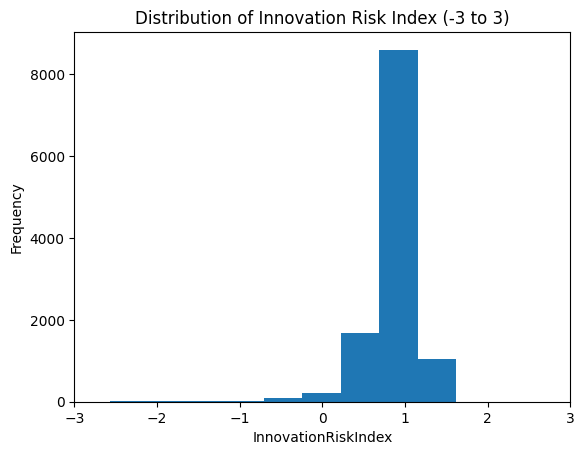

In [24]:
import matplotlib.pyplot as plt

plt.hist(NQPF_risk['InnovationRiskIndex'], bins=50)
plt.xlim(-3, 3)  # restrict x-axis range
plt.title('Distribution of Innovation Risk Index (-3 to 3)')
plt.xlabel('InnovationRiskIndex')
plt.ylabel('Frequency')
plt.show()

# Model Construction

## Task: Lagged Prediction
**Predict the Innovation Risk Index 2 years ahead using current year features**

The target variable is the company's **Innovation Risk Index (from year X+2)**, predicted using financial, market, and innovation features observed in **year X**. 

### Why a 2-Year Lag?
This forward-looking prediction approach:
- **Eliminates data leakage**: Features from year X cannot be caused by risk in year X (different time periods)
- **Provides actionable insight**: Identifies early warning signals that lead to future risk
- **Aligns with business cycles**: A 2-year horizon matches corporate planning and insurance underwriting timelines
- **Tests real predictive power**: Features must have genuine predictive value, not just correlation

### Data Structure
- **Training**: 2020-2021 features → predict 2022-2023 risk
- **Testing**: 2022-2023 features → predict 2024-2025 risk

## Features Used

We predict `RiskIndex_2YearsAhead` using:
- **Financial health**: Interest Coverage Ratio (ICR), Financial Violation flag
- **Market indicators**: Negative Skewness (stock volatility), Market Cap
- **Innovation/Development**: NewTechResDevelop, InnovationOutput, IntangibleAssetsRatio

## Model Selection Guide

| Model | Pros | Cons | Best For |
|-------|------|------|----------|
| **Linear Regression** | Interpretable, fast, shows which features matter | Assumes linear relationships | Baseline, understanding relationships |
| **Random Forest** | Handles non-linearity, robust to outliers | Less interpretable, can overfit | Complex patterns, better accuracy |
| **Decision Tree (CART)** | Very interpretable, handles non-linearity | Can overfit easily | Simple rules, explainability |
| **XGBoost** | High accuracy, handles non-linearity, fast | Complex to interpret | Best predictive performance |

**Our approach**: Train all models and compare which works best for this prediction task

In [25]:
# Step 1: Examine the data
print("Shape of data:", NQPF_risk.shape)
print("\nColumn names:")
print(NQPF_risk.columns.tolist())
print("\nData types:")
print(NQPF_risk.dtypes)
print("\nFirst few rows:")
print(NQPF_risk.head())

Shape of data: (13532, 34)

Column names:
['EndDate', 'InstitutionID', 'Symbol', 'EntProductivityLevel', 'EBIT', 'Interest_Expense', 'Operating Revenue', 'Interest Coverage Ratio(ICR)', 'Financial_Violation_Flag', 'Total Current Assets', 'Total Assets', 'Total Current Liabilities', 'surplus reserve(retained earnings)', 'Total Liabilities', 'Net Intangible Assets', 'Market Cap', 'Negative Skewness', 'NewTechResDevelop', 'InnovationOutput', 'IntangibleAssetsRatio', 'InnovationOutput_filled', 'InnovationRiskIndex', 'RiskIndex_2YearsAhead', 'LivingLabour', 'MaterializedLabor', 'HardTechnology', 'SoftTechnology', 'RDPSalaryRatio', 'RDPersonRatio', 'HighEduPersonRatio', 'DigitalTechInvest', 'RDPDepAmortRatio', 'ProDigitalization', 'OrgDigitalization']

Data types:
EndDate                               datetime64[us]
InstitutionID                                  int64
Symbol                                         int64
EntProductivityLevel                         float64
EBIT               

In [26]:
# Step 2: Select features for modeling
# Target: RiskIndex_2YearsAhead (predict 2-year-ahead risk, not current!)
# Features: financial, market, and innovation indicators FROM CURRENT YEAR

target = 'RiskIndex_2YearsAhead'  # Predicting future risk

# Original features
original_feature_columns = [
    'Interest Coverage Ratio(ICR)',
    'Financial_Violation_Flag',
    'Negative Skewness',
    'Market Cap',
    'NewTechResDevelop',
    'InnovationOutput',
    'IntangibleAssetsRatio'
]

# New features from NQPF_2_LT and NQPF_3_SP - keeping only the most important ones
new_feature_columns = [
    'MaterializedLabor',      # NQPF_2_LT: Materialized labor (fixed assets) - 3rd most important
    'RDPersonRatio',         # NQPF_3_SP: R&D personnel ratio - 5th most important
    'DigitalTechInvest',     # NQPF_3_SP: Digital tech investment - 6th most important
]

# Combine all features - include new ones only if they have some non-null values
feature_columns = original_feature_columns.copy()

# Add new features that have at least some data
for feat in new_feature_columns:
    if feat in NQPF_risk.columns:
        non_null_count = NQPF_risk[feat].notna().sum()
        if non_null_count > 0:
            feature_columns.append(feat)
            print(f"  Adding {feat} ({non_null_count} non-null values)")
        else:
            print(f"  Skipping {feat} (all null values)")
    else:
        print(f"  Feature {feat} not found in data")

print(f"\nTotal features selected: {len(feature_columns)}")
print(f"Features: {feature_columns}")


  Adding MaterializedLabor (11478 non-null values)
  Adding RDPersonRatio (12486 non-null values)
  Adding DigitalTechInvest (12644 non-null values)

Total features selected: 10
Features: ['Interest Coverage Ratio(ICR)', 'Financial_Violation_Flag', 'Negative Skewness', 'Market Cap', 'NewTechResDevelop', 'InnovationOutput', 'IntangibleAssetsRatio', 'MaterializedLabor', 'RDPersonRatio', 'DigitalTechInvest']


In [77]:

# Create modeling dataset
model_data = NQPF_risk[[target] + feature_columns + ['EndDate']].copy()

print("Missing values before cleaning:")
print(model_data.isnull().sum())
print(f"\nTotal rows: {len(model_data)}")
print(f"Total features: {len(feature_columns)}")

# Handle missing values
# Drop rows with missing target or critical features
model_data = model_data.dropna(subset=[target, 'Market Cap', 'Negative Skewness'])

# Fill missing InnovationOutput with 0
model_data['InnovationOutput'] = model_data['InnovationOutput'].fillna(0)

# For new features with many non-null values, fill with median or forward fill approach
for feat in new_feature_columns:
    if feat in model_data.columns:
        non_null_pct = model_data[feat].notna().sum() / len(model_data) * 100
        if non_null_pct > 50:  # If >50% data, fill with median
            median_val = model_data[feat].median()
            model_data[feat] = model_data[feat].fillna(median_val)
        elif non_null_pct > 10:  # If >10%, fill with overall mean by group if possible
            model_data[feat] = model_data[feat].fillna(model_data[feat].mean())

# Drop rows with remaining missing values in critical features
critical_cols = ['Interest Coverage Ratio(ICR)', 'NewTechResDevelop', 'IntangibleAssetsRatio']
model_data = model_data.dropna(subset=critical_cols)

# Handle infinite values in ICR
model_data['Interest Coverage Ratio(ICR)'] = model_data['Interest Coverage Ratio(ICR)'].replace([np.inf, -np.inf], np.nan)
icr_median = model_data['Interest Coverage Ratio(ICR)'].median()
model_data['Interest Coverage Ratio(ICR)'] = model_data['Interest Coverage Ratio(ICR)'].fillna(icr_median)

print(f"\nAfter cleaning: {len(model_data)} rows")
print("\nMissing values after cleaning:")
missing_after = model_data.isnull().sum()
missing_after = missing_after[missing_after > 0]
if len(missing_after) > 0:
    print(missing_after)
else:
    print("No missing values!")
print(f"\nmodel_data shape: {model_data.shape}")
print(f"model_data columns ({len(model_data.columns)}): {model_data.columns.tolist()}")


Missing values before cleaning:
RiskIndex_2YearsAhead           2703
Interest Coverage Ratio(ICR)     864
Financial_Violation_Flag           0
Negative Skewness               1712
Market Cap                       464
NewTechResDevelop                  0
InnovationOutput                   0
IntangibleAssetsRatio           2103
MaterializedLabor               2054
RDPersonRatio                   1046
DigitalTechInvest                888
EndDate                            0
dtype: int64

Total rows: 13532
Total features: 10

After cleaning: 8615 rows

Missing values after cleaning:
No missing values!

model_data shape: (8615, 12)
model_data columns (12): ['RiskIndex_2YearsAhead', 'Interest Coverage Ratio(ICR)', 'Financial_Violation_Flag', 'Negative Skewness', 'Market Cap', 'NewTechResDevelop', 'InnovationOutput', 'IntangibleAssetsRatio', 'MaterializedLabor', 'RDPersonRatio', 'DigitalTechInvest', 'EndDate']


In [78]:
# Step 3: Time-based Train/Test Split (with lagged prediction)
# Early years → training, recent years → testing
# Try predicting 2 years ahead with no data leakage

# Extract year from EndDate
model_data['Year'] = pd.to_datetime(model_data['EndDate']).dt.year

print("Years in data:", sorted(model_data['Year'].unique()))
print("\nReminder: Features from Year X predict risk in Year X+2")
print("2020/2021 features → predict 2022/2023 risk (training)")
print("2022/2023 features → predict 2024/2025 risk (testing)")

# Split: use median year as cutoff
split_year = model_data['Year'].median()
print(f"\nSplit point: Year {split_year}")

train_data = model_data[model_data['Year'] <= split_year].copy()
test_data = model_data[model_data['Year'] > split_year].copy()

print(f"Training samples: {len(train_data)} (years ≤ {split_year})")
print(f"Test samples: {len(test_data)} (years > {split_year})")

# Prepare X and y for training
X_train = train_data[feature_columns]
y_train = train_data[target]

X_test = test_data[feature_columns]
y_test = test_data[target]

print(f"\nFeature matrix shape (train): {X_train.shape}")
print(f"Target shape (train): {y_train.shape}")

Years in data: [np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023)]

Reminder: Features from Year X predict risk in Year X+2
2020/2021 features → predict 2022/2023 risk (training)
2022/2023 features → predict 2024/2025 risk (testing)

Split point: Year 2022.0
Training samples: 6622 (years ≤ 2022.0)
Test samples: 1993 (years > 2022.0)

Feature matrix shape (train): (6622, 10)
Target shape (train): (6622,)


In [79]:
# Step 4: Standardize features (important for Linear Regression, optional for tree-based)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data only (prevent data leakage!)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled features - mean (should be ~0):", X_train_scaled.mean(axis=0).round(3))
print("Scaled features - std (should be ~1):", X_train_scaled.std(axis=0).round(3))

# Convert back to DataFrame for easier tracking
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_columns, index=X_test.index)

Scaled features - mean (should be ~0): [ 0. -0. -0. -0.  0.  0. -0.  0. -0. -0.]
Scaled features - std (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [80]:
# Step 5a: Train Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Dictionary to store models and results
models = {}
results = {}

# 1. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
models['Linear Regression'] = lr_model

y_pred_lr_train = lr_model.predict(X_train_scaled)
y_pred_lr_test = lr_model.predict(X_test_scaled)

results['Linear Regression'] = {
    'train_mse': mean_squared_error(y_train, y_pred_lr_train),
    'train_mae': mean_absolute_error(y_train, y_pred_lr_train),
    'train_r2': r2_score(y_train, y_pred_lr_train),
    'test_mse': mean_squared_error(y_test, y_pred_lr_test),
    'test_mae': mean_absolute_error(y_test, y_pred_lr_test),
    'test_r2': r2_score(y_test, y_pred_lr_test),
}

print("✓ Linear Regression trained")
print(f"  Train R²: {results['Linear Regression']['train_r2']:.4f}")
print(f"  Test R²:  {results['Linear Regression']['test_r2']:.4f}")
print(f"  Test RMSE: {np.sqrt(results['Linear Regression']['test_mse']):.4f}")

✓ Linear Regression trained
  Train R²: 0.6230
  Test R²:  0.7079
  Test RMSE: 0.3719


In [81]:
%pip install xgboost


[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [82]:

# Handle NaN values in scaled data
print("Checking for NaN values in scaled training data:")
nan_col_mask = pd.DataFrame(X_train_scaled).isnull().any()
nan_cols = pd.DataFrame(X_train_scaled).columns[nan_col_mask].tolist()
print(f"Columns with NaN: {nan_cols}")

if len(nan_cols) > 0:
    # Drop rows with NaN values
    valid_idx = ~pd.DataFrame(X_train_scaled).isnull().any(axis=1)
    X_train_scaled = X_train_scaled[valid_idx]
    y_train = y_train[valid_idx]
    
    valid_idx_test = ~pd.DataFrame(X_test_scaled).isnull().any(axis=1)
    X_test_scaled = X_test_scaled[valid_idx_test]
    y_test = y_test[valid_idx_test]
    
    print(f"After removing NaN: train {len(X_train_scaled)}, test {len(X_test_scaled)}")
else:
    print("No NaN values found!")

# Alternative: Impute with mean
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_train_scaled = imputer.fit_transform(X_train_scaled)
X_test_scaled = imputer.transform(X_test_scaled)

print(f"After imputation: train shape {X_train_scaled.shape}, test shape {X_test_scaled.shape}")
print(f"NaN in X_train_scaled after imputation: {np.isnan(X_train_scaled).sum()}")
print(f"NaN in X_test_scaled after imputation: {np.isnan(X_test_scaled).sum()}")


Checking for NaN values in scaled training data:
Columns with NaN: []
No NaN values found!
After imputation: train shape (6622, 10), test shape (1993, 10)
NaN in X_train_scaled after imputation: 0
NaN in X_test_scaled after imputation: 0


In [83]:

# Also update X_train and X_test (unscaled) to match the cleaned scaled versions
# Get the indices of valid rows
valid_train_idx = ~(X_train_scaled == X_train_scaled).all(axis=1)  # All rows with any difference
# Actually, just filter based on y_train length
valid_train_idx = X_train.index[:len(y_train)]
valid_test_idx = X_test.index[:len(y_test)]

# Update unscaled versions
X_train = X_train.iloc[:len(y_train)]
X_test = X_test.iloc[:len(y_test)]

print(f"Aligned unscaled data: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"                      X_test {X_test.shape}, y_test {y_test.shape}")
print(f"Aligned scaled data:   X_train_scaled {X_train_scaled.shape}, X_test_scaled {X_test_scaled.shape}")


Aligned unscaled data: X_train (6622, 10), y_train (6622,)
                      X_test (1993, 10), y_test (1993,)
Aligned scaled data:   X_train_scaled (6622, 10), X_test_scaled (1993, 10)


In [84]:
# Step 5a: Train Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import numpy as np

# Dictionary to store models and results
models = {}
results = {}

# 1. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
models['Linear Regression'] = lr_model

y_pred_lr_train = lr_model.predict(X_train_scaled)
y_pred_lr_test = lr_model.predict(X_test_scaled)

results['Linear Regression'] = {
    'train_mse': mean_squared_error(y_train, y_pred_lr_train),
    'train_mae': mean_absolute_error(y_train, y_pred_lr_train),
    'train_r2': r2_score(y_train, y_pred_lr_train),
    'test_mse': mean_squared_error(y_test, y_pred_lr_test),
    'test_mae': mean_absolute_error(y_test, y_pred_lr_test),
    'test_r2': r2_score(y_test, y_pred_lr_test),
}

print("✓ Linear Regression trained")
print(f"  Train R²: {results['Linear Regression']['train_r2']:.4f}")
print(f"  Test R²:  {results['Linear Regression']['test_r2']:.4f}")
print(f"  Test RMSE: {np.sqrt(results['Linear Regression']['test_mse']):.4f}")

✓ Linear Regression trained
  Train R²: 0.6230
  Test R²:  0.7079
  Test RMSE: 0.3719


In [85]:
# Step 5c: Train Decision Tree (CART)

dt_model = DecisionTreeRegressor(
    max_depth=8,           # control complexity
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
dt_model.fit(X_train, y_train)
models['Decision Tree'] = dt_model

y_pred_dt_train = dt_model.predict(X_train)
y_pred_dt_test = dt_model.predict(X_test)

results['Decision Tree'] = {
    'train_mse': mean_squared_error(y_train, y_pred_dt_train),
    'train_mae': mean_absolute_error(y_train, y_pred_dt_train),
    'train_r2': r2_score(y_train, y_pred_dt_train),
    'test_mse': mean_squared_error(y_test, y_pred_dt_test),
    'test_mae': mean_absolute_error(y_test, y_pred_dt_test),
    'test_r2': r2_score(y_test, y_pred_dt_test),
}

print("✓ Decision Tree trained")
print(f"  Train R²: {results['Decision Tree']['train_r2']:.4f}")
print(f"  Test R²:  {results['Decision Tree']['test_r2']:.4f}")
print(f"  Test RMSE: {np.sqrt(results['Decision Tree']['test_mse']):.4f}")

✓ Decision Tree trained
  Train R²: 0.8171
  Test R²:  0.5960
  Test RMSE: 0.4374


In [86]:
# Step 5b: Train Random Forest
# Note: Random Forest doesn't require scaled features, but scaling does no harm

rf_model = RandomForestRegressor(
    n_estimators=100,      # number of trees
    max_depth=15,          # prevent overfitting
    min_samples_split=5,   
    min_samples_leaf=2,
    random_state=42
)
rf_model.fit(X_train, y_train)  # Use unscaled data
models['Random Forest'] = rf_model

y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_test = rf_model.predict(X_test)

results['Random Forest'] = {
    'train_mse': mean_squared_error(y_train, y_pred_rf_train),
    'train_mae': mean_absolute_error(y_train, y_pred_rf_train),
    'train_r2': r2_score(y_train, y_pred_rf_train),
    'test_mse': mean_squared_error(y_test, y_pred_rf_test),
    'test_mae': mean_absolute_error(y_test, y_pred_rf_test),
    'test_r2': r2_score(y_test, y_pred_rf_test),
}

print("✓ Random Forest trained")
print(f"  Train R²: {results['Random Forest']['train_r2']:.4f}")
print(f"  Test R²:  {results['Random Forest']['test_r2']:.4f}")
print(f"  Test RMSE: {np.sqrt(results['Random Forest']['test_mse']):.4f}")

✓ Random Forest trained
  Train R²: 0.8237
  Test R²:  0.6883
  Test RMSE: 0.3842


In [87]:
# Step 5d: Train XGBoost

xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
models['XGBoost'] = xgb_model

y_pred_xgb_train = xgb_model.predict(X_train)
y_pred_xgb_test = xgb_model.predict(X_test)

results['XGBoost'] = {
    'train_mse': mean_squared_error(y_train, y_pred_xgb_train),
    'train_mae': mean_absolute_error(y_train, y_pred_xgb_train),
    'train_r2': r2_score(y_train, y_pred_xgb_train),
    'test_mse': mean_squared_error(y_test, y_pred_xgb_test),
    'test_mae': mean_absolute_error(y_test, y_pred_xgb_test),
    'test_r2': r2_score(y_test, y_pred_xgb_test),
}

print("✓ XGBoost trained")
print(f"  Train R²: {results['XGBoost']['train_r2']:.4f}")
print(f"  Test R²:  {results['XGBoost']['test_r2']:.4f}")
print(f"  Test RMSE: {np.sqrt(results['XGBoost']['test_mse']):.4f}")

✓ XGBoost trained
  Train R²: 0.8080
  Test R²:  0.6031
  Test RMSE: 0.4335


MODEL COMPARISON - TEST SET PERFORMANCE (LAGGED PREDICTION)
                    Test R²  Test RMSE  Test MAE
Linear Regression  0.707894   0.371912  0.182642
Decision Tree      0.596034   0.437364  0.197371
Random Forest      0.688317   0.384173  0.181180
XGBoost            0.603085   0.433530  0.187510

OVERFITTING CHECK (Train R² - Test R²)
                   Train R²   Test R²  Difference
Linear Regression  0.622956  0.707894   -0.084938
Decision Tree      0.817086  0.596034    0.221052
Random Forest      0.823740  0.688317    0.135423
XGBoost            0.808017  0.603085    0.204932

High difference = possible overfitting (memorizing training data)


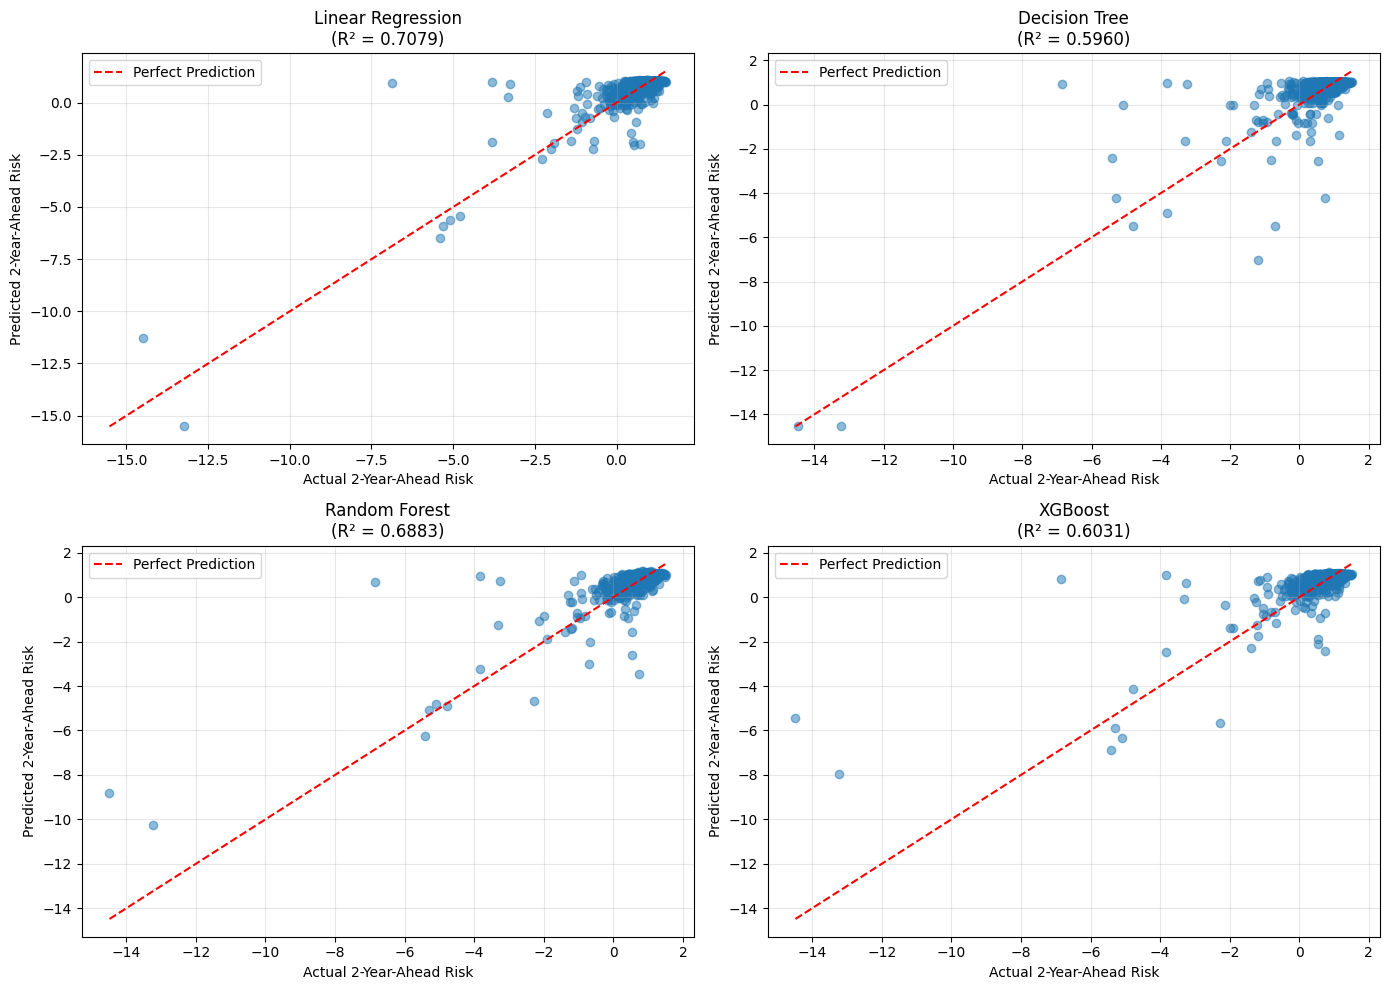

In [46]:
import matplotlib.pyplot as plt

print("="*70)
print("MODEL COMPARISON - TEST SET PERFORMANCE (LAGGED PREDICTION)")
print("="*70)

comparison_df = pd.DataFrame({
    'Test R²': [results[m]['test_r2'] for m in models.keys()],
    'Test RMSE': [np.sqrt(results[m]['test_mse']) for m in models.keys()],
    'Test MAE': [results[m]['test_mae'] for m in models.keys()],
})
comparison_df.index = models.keys()

print(comparison_df)

# Find best model by R²
# best_model_name = comparison_df['Test R²'].idxmax()
# print(f"\n🏆 Best model by Test R²: {best_model_name}")

# Check for overfitting
print("\n" + "="*70)
print("OVERFITTING CHECK (Train R² - Test R²)")
print("="*70)
overfitting_df = pd.DataFrame({
    'Train R²': [results[m]['train_r2'] for m in models.keys()],
    'Test R²': [results[m]['test_r2'] for m in models.keys()],
    'Difference': [results[m]['train_r2'] - results[m]['test_r2'] for m in models.keys()],
})
overfitting_df.index = models.keys()
print(overfitting_df)
print("\nHigh difference = possible overfitting (memorizing training data)")

# Visualize test predictions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (model_name, model) in enumerate(models.items()):
    if model_name == 'Linear Regression':
        y_pred = y_pred_lr_test
    elif model_name == 'Random Forest':
        y_pred = y_pred_rf_test
    elif model_name == 'Decision Tree':
        y_pred = y_pred_dt_test
    else:  # XGBoost
        y_pred = y_pred_xgb_test
    
    axes[idx].scatter(y_test, y_pred, alpha=0.5)
    
    # Add perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
    
    axes[idx].set_xlabel('Actual 2-Year-Ahead Risk')
    axes[idx].set_ylabel('Predicted 2-Year-Ahead Risk')
    axes[idx].set_title(f'{model_name}\n(R² = {results[model_name]["test_r2"]:.4f})')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()


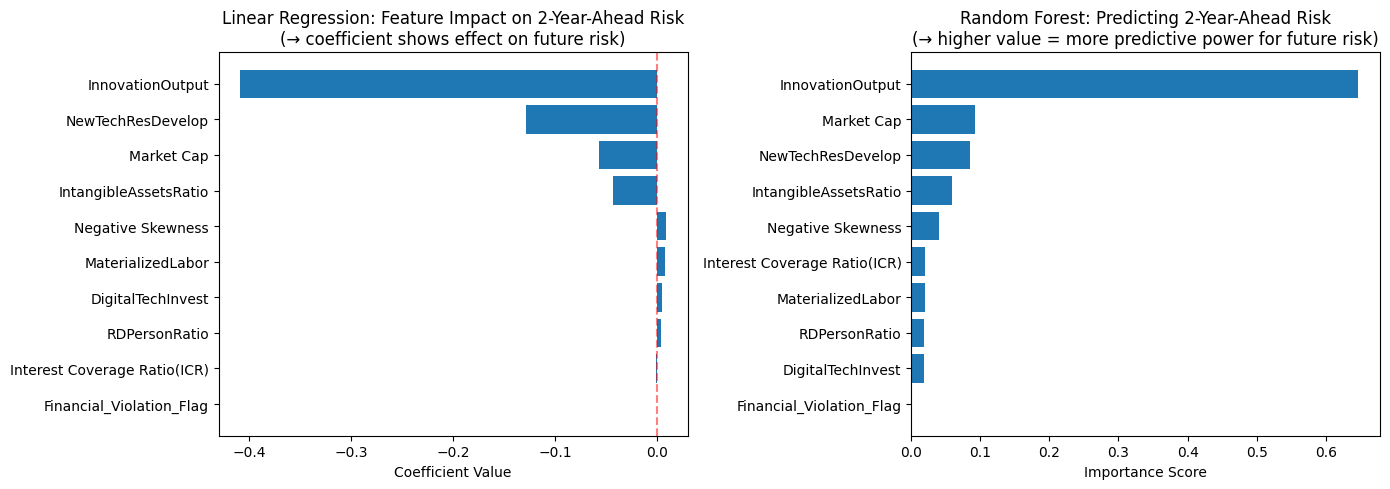

FEATURE IMPORTANCE (Real Predictive Value, Not Engineered)

Linear Regression Coefficients:
                        Feature  Coefficient
1      Financial_Violation_Flag     0.000158
0  Interest Coverage Ratio(ICR)    -0.000379
8                 RDPersonRatio     0.004526
9             DigitalTechInvest     0.005383
7             MaterializedLabor     0.008168
2             Negative Skewness     0.009147
6         IntangibleAssetsRatio    -0.043252
3                    Market Cap    -0.056766
4             NewTechResDevelop    -0.128115
5              InnovationOutput    -0.409159

Random Forest Feature Importance:
                        Feature  Importance
1      Financial_Violation_Flag    0.000517
9             DigitalTechInvest    0.018656
8                 RDPersonRatio    0.018719
7             MaterializedLabor    0.020083
0  Interest Coverage Ratio(ICR)    0.020386
2             Negative Skewness    0.039743
6         IntangibleAssetsRatio    0.059572
4             NewTechResDe

In [47]:
# Step 7: Feature Importance Analysis

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression: Coefficients
lr_coeffs = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=True)

axes[0].barh(lr_coeffs['Feature'], lr_coeffs['Coefficient'])
axes[0].set_xlabel('Coefficient Value')
axes[0].set_title('Linear Regression: Feature Impact on 2-Year-Ahead Risk\n(→ coefficient shows effect on future risk)')
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.5)

# Random Forest: Feature Importance
rf_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1].barh(rf_importance['Feature'], rf_importance['Importance'])
axes[1].set_xlabel('Importance Score')
axes[1].set_title('Random Forest: Predicting 2-Year-Ahead Risk\n(→ higher value = more predictive power for future risk)')

plt.tight_layout()
plt.show()

print("="*70)
print("FEATURE IMPORTANCE (Real Predictive Value, Not Engineered)")
print("="*70)
print("\nLinear Regression Coefficients:")
print(lr_coeffs)
print("\nRandom Forest Feature Importance:")
print(rf_importance)